In [1]:
import sys
sys.path.append("..")

In [2]:
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 20) # tomo solo las 20 primeras imágenes
subdataset_processed = CTManager.process_batch(subdataset)
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)

Cargando subconjunto de datos (Primeras 20 imágenes)...
  -> Cargado subconjunto Bleeding: (20, 512, 512)
  -> Cargado subconjunto Ischemia: (20, 512, 512)
  -> Cargado subconjunto Normal: (20, 512, 512)


## Brain Extractor
Separo los cerebros de las imagenes del resto de tejido y lo almaceno en una key al mismo nivel de 'dicom' y 'overlay' llamada 'brain'

In [3]:
from brain_extraction.brain_extractor import BrainExtractorManager

al colocar plot_example = True puedo visualizar la primera extracción para cada clase (Normal, Bleeding, Inschemia).

Iniciando extracción de cerebros...
  -> Procesando clase: Bleeding (20 imágenes)


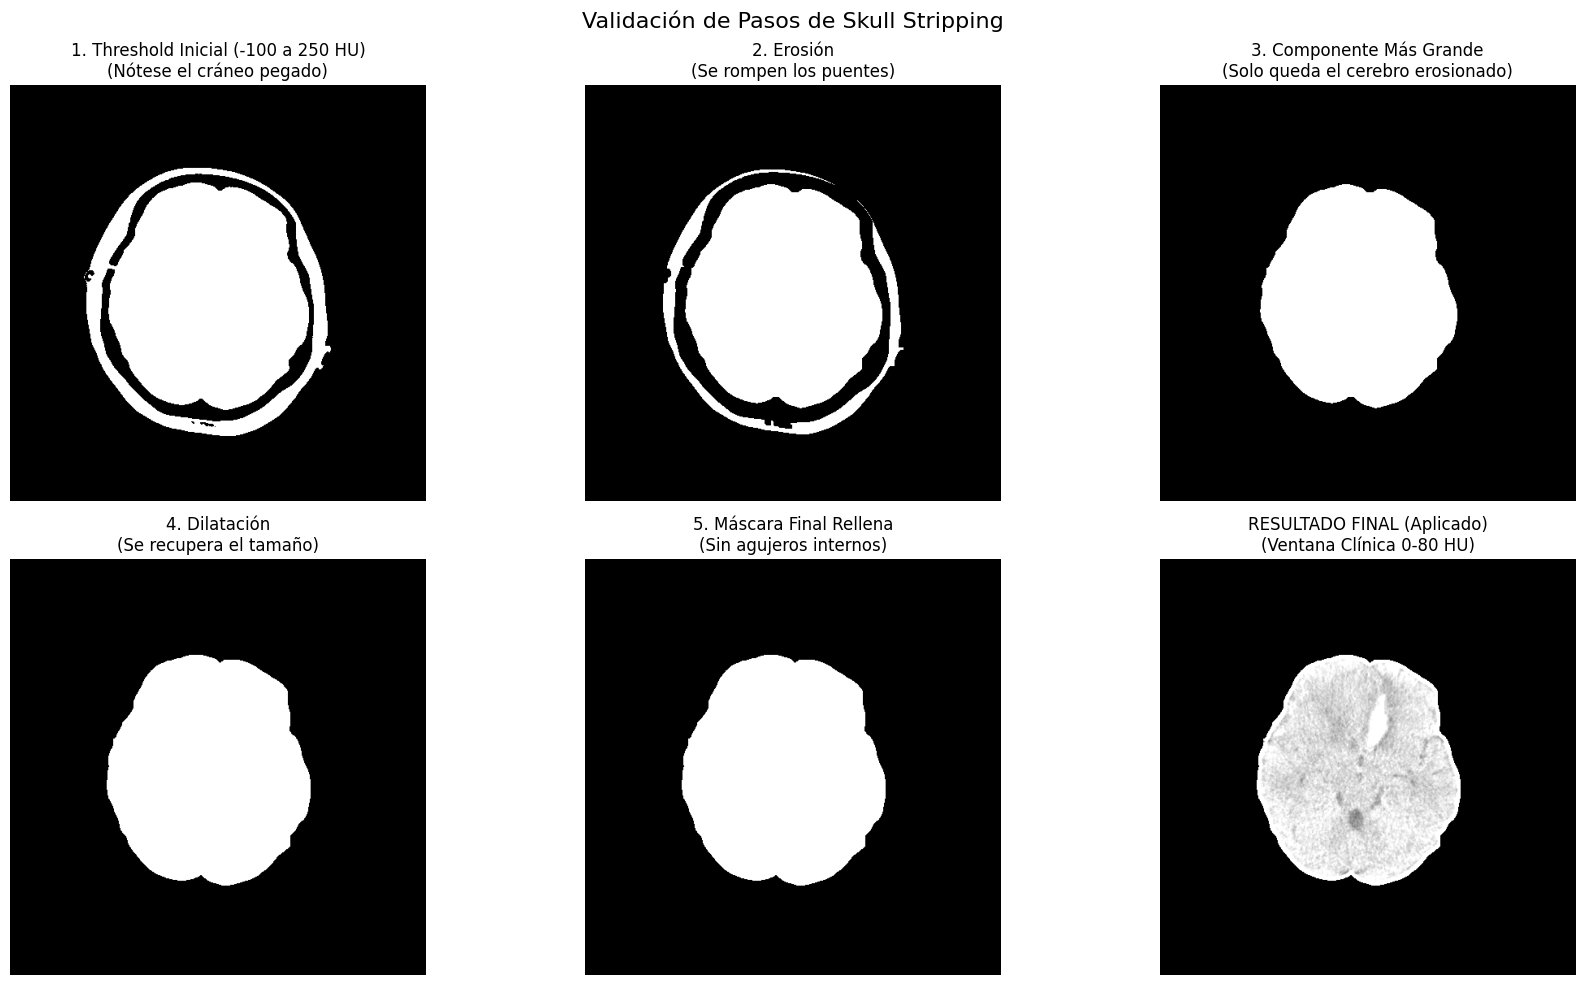

  -> Procesando clase: Ischemia (20 imágenes)


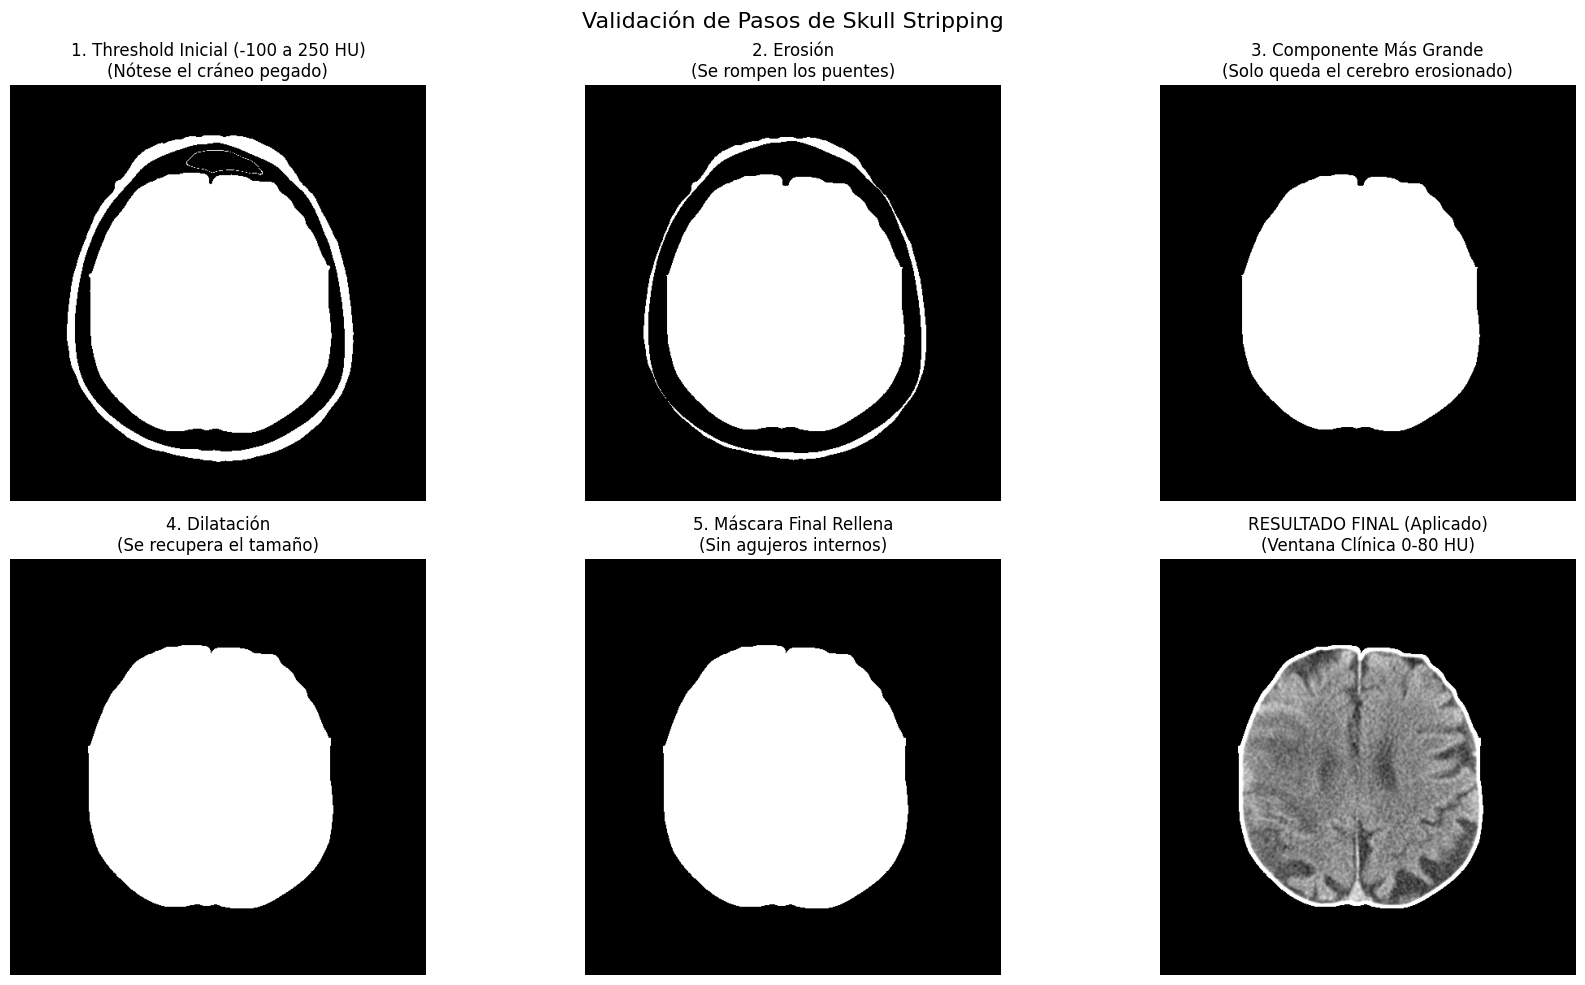

  -> Procesando clase: Normal (20 imágenes)


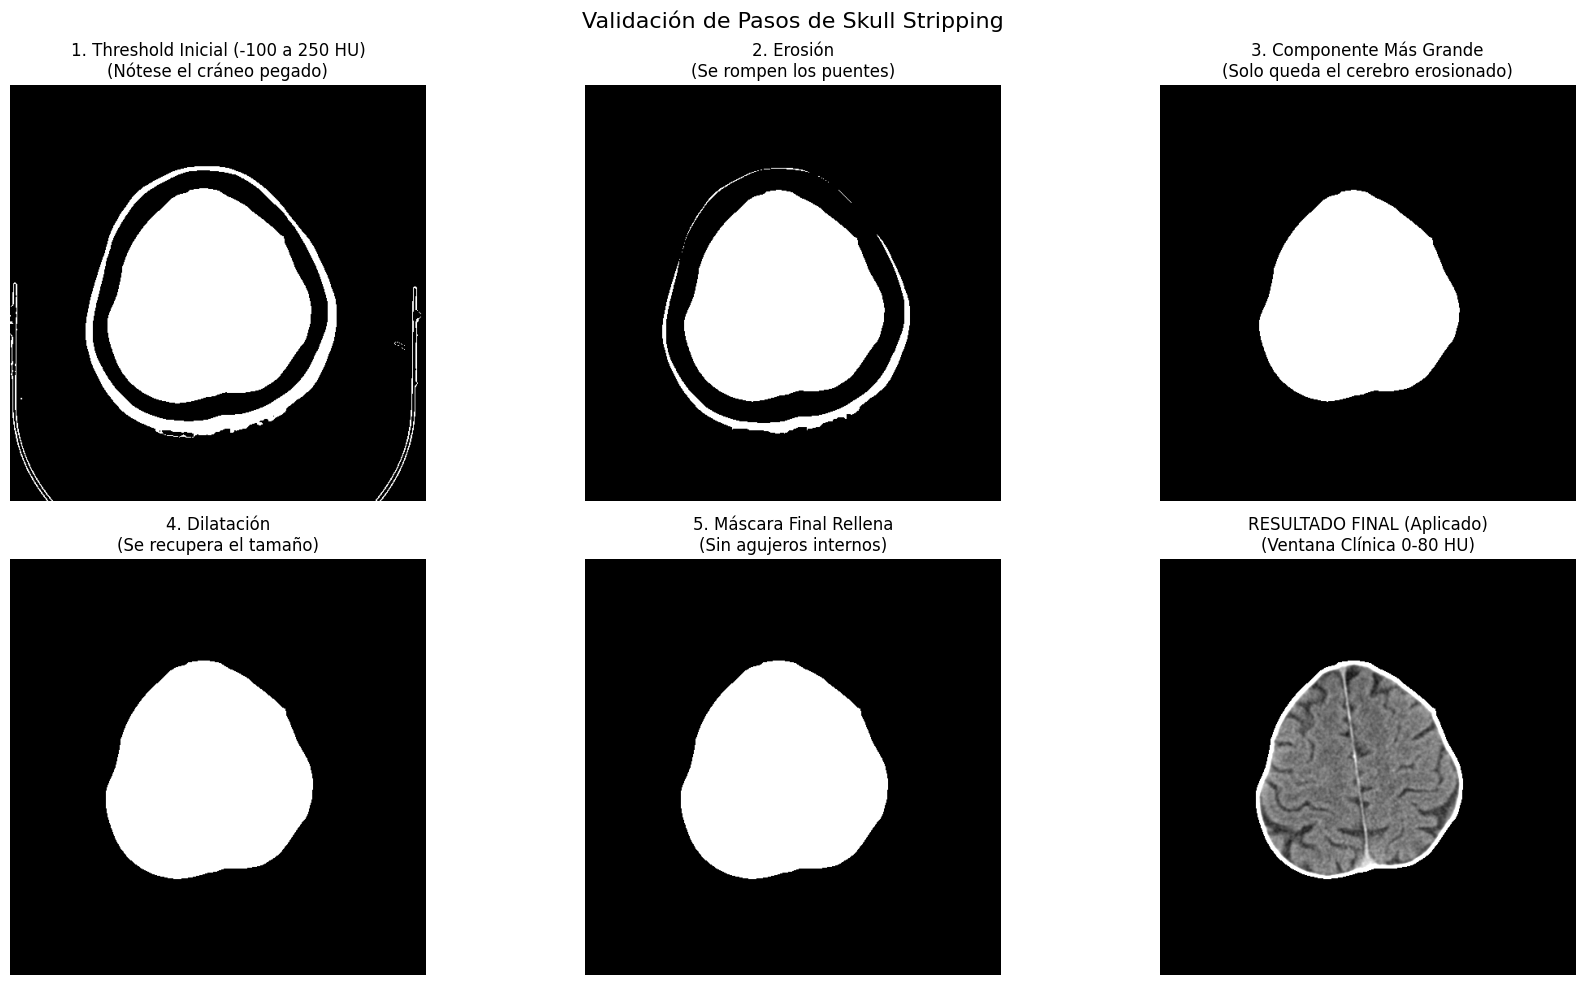

Extracción completada.


In [4]:
brain_manager = BrainExtractorManager(subdataset_filtered)
dataset_final = brain_manager.extract_all_brains(plot_examples=True)

In [5]:
print(f"Forma del Dicom: {dataset_final['Bleeding']['dicom'].shape}")
print(f"Forma del Overlay: {dataset_final['Bleeding']['overlay'].shape}")
print(f"Forma del Brain: {dataset_final['Bleeding']['brain'].shape}")

Forma del Dicom: (20, 512, 512)
Forma del Overlay: (20, 512, 512)
Forma del Brain: (20, 512, 512)
